<a href="https://colab.research.google.com/github/Steven111030/-AI/blob/main/GenAI_ML_HW5_Regression_clean.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 2025 GENAI-ML-HW5
# Regression
In this assignment, you are expected to use linear regression and multi layer perceptron (MLP) model to predict the metacritic score on the famous game platform, Steam. For more information, please check the homework slide.
HW5 Slide Link :

https://docs.google.com/presentation/d/1ysys__L1HKLPV2LX0u-KMP0LD1XamhNCY_hq29k-I0A/edit?usp=sharing



## Check GPU Status

In [ ]:
!nvidia-smi

Mon Nov 10 14:11:54 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   34C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# Import Modules


In [ ]:
import random
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from tqdm import tqdm
import matplotlib.pyplot as plt


# Set Random Seed

In [ ]:
# ===== 設定亂數種子，可以固定結果 =====
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

# TODO - 自行選擇亂數種子
set_seed(20251110)

# Download Dataset

In [ ]:
!git clone https://github.com/murphy-cthsu/GENAI-ML-2025-HW5-Data.git
!mv GENAI-ML-2025-HW5-Data/*.csv .



fatal: destination path 'GENAI-ML-2025-HW5-Data' already exists and is not an empty directory.
mv: cannot stat 'GENAI-ML-2025-HW5-Data/*.csv': No such file or directory


# Preview Training Data

In [ ]:
# ===== 載入訓練資料集 =====
train_df = pd.read_csv("train.csv")
# 預覽資料集
row_index = 0
row = train_df.iloc[row_index]
for col, val in row.items():
    if isinstance(val, str) and len(val) > 100:
        print(f"{col:25}: {val[:100]}...")   # truncate long text
    else:
        print(f"{col:25}: {val}")
# 數值與文字特徵
numeric_features = [c for c in train_df.select_dtypes(include=['number']).columns if c != 'metacritic_score']
print("All available numeric features :", numeric_features)
print("All available text features :", train_df.select_dtypes(include=['object']).columns.tolist())

appid                    : 249130
name                     : LEGO® Marvel™ Super Heroes
release_date             : 1382400000
required_age             : 0
price                    : 19.99
dlc_count                : 2
detailed_description     : LEGO® Marvel™ Super Heroes features an original story crossing the entire Marvel Universe. Players t...
about_the_game           : LEGO® Marvel™ Super Heroes features an original story crossing the entire Marvel Universe. Players t...
short_description        : LEGO® Marvel™ Super Heroes features an original story crossing the entire Marvel Universe. Players t...
reviews                  : nan
windows                  : 1
mac                      : 0
linux                    : 0
achievements             : 45
recommendations          : 18110
positive                 : 24279
negative                 : 1196
estimated_owners         : 1500000
average_playtime_forever : 0
average_playtime_2weeks  : 0
median_playtime_forever  : 0
median_playtime_2weeks

# Load Data

In [ ]:
print("All availbale numeric features :", train_df.select_dtypes(include=['number']).columns.tolist())

All availbale numeric features : ['appid', 'release_date', 'required_age', 'price', 'dlc_count', 'windows', 'mac', 'linux', 'achievements', 'recommendations', 'positive', 'negative', 'estimated_owners', 'average_playtime_forever', 'average_playtime_2weeks', 'median_playtime_forever', 'median_playtime_2weeks', 'discount', 'peak_ccu', 'pct_pos_total', 'num_reviews_total', 'pct_pos_recent', 'num_reviews_recent', 'has_website', 'has_support_url', 'has_support_email', 'support_english', 'support_japanese', 'support_spanish', 'support_chinese', 'support_french', 'is_top_20_developers', 'is_top_20_publishers', 'is_action', 'is_adventure', 'is_rpg', 'is_f2p', 'is_strategy', 'num_screenshots', 'num_movies', 'metacritic_score']


In [ ]:

# #appid：應用程式編號（遊戲ID）
# release_date：發行日期
# required_age：限制年齡
# price：價格
# dlc_count：DLC 數量
# windows：是否支援 Windows
# mac：是否支援 macOS
# linux：是否支援 Linux
# achievements：成就數量
# recommendations：推薦次數（玩家建議數）
# positive：好評數量
# negative：差評數量
# estimated_owners：預估擁有者人數
# average_playtime_forever：平均總遊玩時間
# average_playtime_2weeks：最近兩週平均遊玩時間
# median_playtime_forever：總遊玩時間中位數
# median_playtime_2weeks：最近兩週遊玩時間中位數
# discount：折扣百分比
# peak_ccu：同時線上人數峰值（Concurrent Users）
# pct_pos_total：總體好評百分比
# num_reviews_total：總評論數
# pct_pos_recent：近期好評百分比
# num_reviews_recent：近期評論數
# has_website：是否有官方網站
# has_support_url：是否有客服網址
# has_support_email：是否有客服電子郵件
# support_english：是否支援英文客服
# support_japanese：是否支援日文客服
# support_spanish：是否支援西班牙文客服
# support_chinese：是否支援中文客服
# support_french：是否支援法文客服
# is_top_20_developers：是否為前20大開發商
# is_top_20_publishers：是否為前20大發行商
# is_action：是否屬於動作類遊戲
# is_adventure：是否屬於冒險類遊戲
# is_rpg：是否屬於角色扮演類（RPG）遊戲
# is_f2p：是否為免費遊玩（Free to Play）
# is_strategy：是否屬於策略類遊戲
# num_screenshots：遊戲截圖數量
# num_movies：遊戲影片數量

# TODO(Boss baseline) - Feature Selection: 選擇適合的features進行訓練，可選features請參見csv檔欄位
# To check all available numeric features, uncomment the line below :
# print("All availbale numeric features :", train_df.select_dtypes(include=['number']).columns.tolist())
numeric_features = ['recommendations', 'positive', 'negative','price','average_playtime_forever','peak_ccu',
                    'pct_pos_total','num_reviews_total']

X_numeric = train_df[numeric_features].fillna(0).values
y = train_df['metacritic_score'].fillna(0).values.reshape(-1, 1)


# 預設只使用數值特徵
X = X_numeric

# TODO(Boss baseline) - Feature Selection: 使用文字欄位的Embedding捕捉特徵

# 如果想要使用embedding，可以取消以下程式碼註解
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA

# 要進行embedding的文字欄位
text_columns = ['reviews','short_description']

embedder = SentenceTransformer('all-mpnet-base-v2')

def extract_embeddings(df, col):
    print(f"Embedding column: {col}")
    texts = df[col].fillna("").astype(str).tolist()
    emb = embedder.encode(texts, batch_size=64, show_progress_bar=True, convert_to_numpy=True)
    return emb

def reduce_dim_with_pca(embeddings, n_components=64):
    pca = PCA(n_components=n_components)
    reduced = pca.fit_transform(embeddings)
    return reduced, pca

# 建立embeddings並用PCA降維
embeddings_reduced = []
pca_models = {}
for col in text_columns:
    emb = extract_embeddings(train_df, col)
    emb_reduced, pca_model = reduce_dim_with_pca(emb, n_components=100)
    embeddings_reduced.append(emb_reduced)
    pca_models[col] = pca_model

X_text_reduced = np.concatenate(embeddings_reduced, axis=1)

# 將數值特徵與文字特徵結合
X = np.concatenate([X_numeric, X_text_reduced], axis=1)


# ===== 對資料進行標準化 =====
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
target_scaler = StandardScaler()
y_scaled = target_scaler.fit_transform(y)

# ===== 切分 train/valid set: 可以自行調整訓練集與驗證集的比例 =====
X_train, X_dev, y_train, y_dev = train_test_split(X_scaled, y_scaled, test_size=0.25, random_state=42)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding column: reviews


Batches:   0%|          | 0/50 [00:00<?, ?it/s]

Embedding column: short_description


Batches:   0%|          | 0/50 [00:00<?, ?it/s]

# Dataset Class


In [ ]:
# ===== 資料集 =====
class SteamDataset(Dataset):
    def __init__(self, features, targets):
        self.features = torch.tensor(features, dtype=torch.float32)
        self.targets = torch.tensor(targets, dtype=torch.float32)
    def __len__(self):
        return len(self.features)
    def __getitem__(self, idx):
        return self.features[idx], self.targets[idx]

# Model Class

In [ ]:
# TODO(Strong baseline) - 模型架構: 自行調整模型架構以提高模型能力
# class LinearModel(nn.Module):
#     def __init__(self, input_dim):
#         super().__init__()
#         self.fc = nn.Linear(input_dim, 1)

#     def forward(self, x):
#         return self.fc(x)

class MLPModel(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 128), dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]), # 第一層：input_dim -> 128，後接ReLU，好處是能夠引入非線性，讓模型學習更複雜的模式
            nn.ReLU(),
            nn.Dropout(dropout), # 設置Dropout能夠防止overfitting
            nn.Linear(hidden_dims[0], hidden_dims[1]), # 中間層：128 -> 64，接ReLU
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dims[1], 1), # 輸出層：64 -> 1
        )

    def forward(self, x):
        return self.net(x)

# Hyperparameter


In [ ]:
# TODO(Medium baseline) - Training Hyperparameters: 自行調整訓練超參數來改善模型表現
n_epochs = 5000          # 訓練回合數
learning_rate = 1e-4     # 學習率
batch_size = 16         # 每次訓練取多少樣本
weight_decay = 1e-5         # L2 regularization強度，緩解overfitting。Useful Reference:https://medium.com/analytics-vidhya/deep-learning-basics-weight-decay-3c68eb4344e9
shuffle_data = True      # 是否在每個 epoch 打亂資料訓練


# Train

Training Progress:   1%|          | 50/5000 [00:15<24:59,  3.30it/s]

Epoch 50: Train Loss=0.1192, Val RMSE=4.1873


Training Progress:   2%|▏         | 100/5000 [00:30<24:07,  3.39it/s]

Epoch 100: Train Loss=0.0681, Val RMSE=4.2565


Training Progress:   3%|▎         | 150/5000 [00:46<28:40,  2.82it/s]

...

Epoch 4900: Train Loss=0.0129, Val RMSE=4.5427


Training Progress:  99%|█████████▉| 4950/5000 [25:10<00:14,  3.44it/s]

Epoch 4950: Train Loss=0.0129, Val RMSE=4.4949


Training Progress: 100%|██████████| 5000/5000 [25:25<00:00,  3.28it/s]

Epoch 5000: Train Loss=0.0121, Val RMSE=4.5316


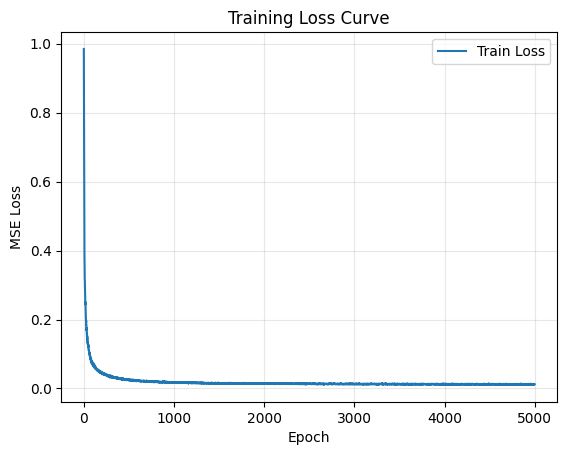

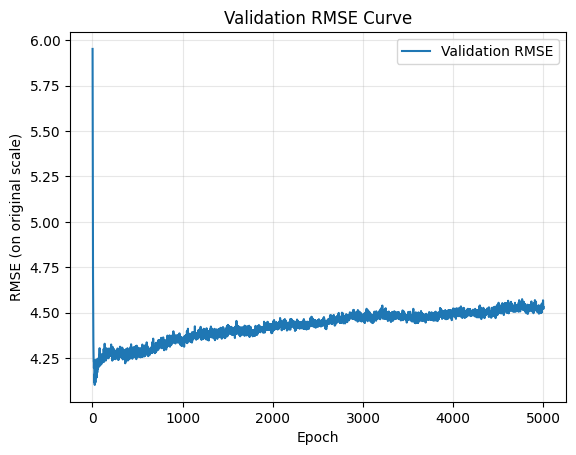

In [ ]:

# ===== 用DataLoader讀取資料集 =====
train_set = SteamDataset(X_train, y_train)
dev_set = SteamDataset(X_dev, y_dev)
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=shuffle_data)
dev_loader = DataLoader(dev_set, batch_size=batch_size, shuffle=False)

# ===== Model / Optimizer / Loss =====
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLPModel(input_dim=X_train.shape[1]).to(device)  # TODO(Strong baseline) - 也可以換成 MLPModel
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
loss_fn = nn.MSELoss()
# ===== 訓練迴圈 =====
train_loss_history = []
val_rmse_history = []
for epoch in tqdm(range(n_epochs), desc="Training Progress"):
    model.train()
    total_loss = 0
    for x_batch, y_batch in train_loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        preds = model(x_batch)
        loss = loss_fn(preds, y_batch)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    avg_loss = total_loss / len(train_loader)
    train_loss_history.append(avg_loss)
    # 驗證
    model.eval()
    preds_list, y_true_list = [], []
    with torch.no_grad():
        for x_batch, y_batch in dev_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
            preds = model(x_batch)
            preds_list.append(preds.cpu().numpy())  # move back to CPU for numpy
            y_true_list.append(y_batch.cpu().numpy())
    y_pred_raw = np.vstack(preds_list)
    y_true_raw = np.vstack(y_true_list)

    y_pred_inv = target_scaler.inverse_transform(y_pred_raw)
    y_true_inv = target_scaler.inverse_transform(y_true_raw)

    rmse = np.sqrt(mean_squared_error(y_true_inv, y_pred_inv))
    val_rmse_history.append(rmse)

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1}: Train Loss={avg_loss:.4f}, Val RMSE={rmse:.4f}")
# ===== Plot Curves =====
epochs = np.arange(1, n_epochs + 1)

plt.figure()
plt.plot(epochs, train_loss_history, label="Train Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure()
plt.plot(epochs, val_rmse_history, label="Validation RMSE")
plt.xlabel("Epoch")
plt.ylabel("RMSE (on original scale)")
plt.title("Validation RMSE Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# Inference on Test Dataset

In [ ]:
# ===== 載入測試集 =====
test_df = pd.read_csv("test.csv")

# 處理測試集 numeric 特徵
X_test_num = test_df[numeric_features].fillna(0).values
X_test_combined = np.hstack([X_test_num])

# TODO: If sentence embedding used.

# 如果有使用embedding，請取消以下程式碼註解
# 處理文字embedding
reviews_embed = embedder.encode(test_df["reviews"].fillna("").astype(str).tolist(),
                               batch_size=64, show_progress_bar=True, convert_to_numpy=True)
short_desc_embed = embedder.encode(test_df["short_description"].fillna("").astype(str).tolist(),
                                   batch_size=64, show_progress_bar=True, convert_to_numpy=True)

# 用train時的PCA來降維
reviews_embed_reduced = pca_models['reviews'].transform(reviews_embed)
short_desc_embed_reduced = pca_models['short_description'].transform(short_desc_embed)

# 合併numeric+embedding
X_test_combined = np.hstack([X_test_num, reviews_embed_reduced, short_desc_embed_reduced])

# 用 train 的 scaler transform (跟 train 特徵維度一致)
X_test_scaled = scaler.transform(X_test_combined)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32).to(device)

# ===== 模型推論 =====
model.eval()
with torch.no_grad():
    preds_scaled = model(X_test_tensor).cpu().numpy()
    preds = target_scaler.inverse_transform(preds_scaled).squeeze()

submission = pd.DataFrame({
    "appid": test_df["appid"],
    "metacritic_score": np.round(preds).astype(int)
})
submission.to_csv("submission.csv", index=False)
print("Output saved to submission.csv")

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Output saved to submission.csv


In [ ]:
import json

path = '/content/drive/MyDrive/Colab Notebooks/GenAI-ML-HW5-Regression.ipynb'  # 例如 '/content/my_notebook.ipynb'

# 讀取
with open(path, 'r', encoding='utf-8') as f:
    nb = json.load(f)

# 移除 metadata.widgets 欄位
if 'widgets' in nb.get('metadata', {}):
    del nb['metadata']['widgets']

# 儲存乾淨版本
clean_path = path.replace('.ipynb', '_clean.ipynb')
with open(clean_path, 'w', encoding='utf-8') as f:
    json.dump(nb, f, ensure_ascii=False, indent=2)

print(f"✅ Cleaned notebook saved as: {clean_path}")


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/GenAI-ML-HW5-Regression.ipynb'